In [13]:
# the core goal with the knn is to find movies that have similar multipliers.
# the way that this will be tested is that I will change the knn in supabase and then rerun this
# this will select 400 most recent movies
# then it will get the first 60 box office days for each of the 10 knn'd movies
# then it will get the multipliers for each day
# then it will compare those multipliers to the original movie
# then it will get the mape for each of the 10 knn'd movies to the original movie for each of the 100 movies
# then it will print the average and median mape

from database.types import FirstDaysMultiRPC, Movie, BulkKNNRPC
from database.db import supabase
from modeling.day_tags import get_adjustment_weight
import datetime as dt
from typing import TypedDict
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

movies_to_get = 50

movies: list[Movie] = (
    supabase.table("movie")
    .select("*")
    .lt("release_date", dt.datetime.now() - dt.timedelta(days=45))
    .order("release_date", desc=True)
    .limit(movies_to_get)
    .execute()
    .data
)

days_to_compare = 60

# get the first 60 box office days for each of the 10 knn'd movies
# use the first_days_multi rpc function
movie_ids = [movie["id"] for movie in movies]
first_days: list[FirstDaysMultiRPC] = (
    supabase.rpc("first_days_multi", {"movie_ids": movie_ids, "x": days_to_compare})
    .execute()
    .data
)


In [14]:
# then do knn on each of the movies
bulk_knn: list[BulkKNNRPC] = (
    supabase.rpc("bulk_knn", {"movie_ids": movie_ids, "k": 10, "restrict_before": True})
    .execute()
    .data
)

knn_ids_set = set()

movie_to_knn: dict[str, list[str]] = {}

for movie in bulk_knn:
    if movie["similar_id"] not in movie_to_knn:
        movie_to_knn[movie["similar_id"]] = []
    movie_to_knn[movie["similar_id"]].append(movie["return_id"])
    knn_ids_set.add(movie["return_id"])

# then get the first_days_multi for all of these
knn_ids = list(knn_ids_set)

knn_first_days: list[FirstDaysMultiRPC] = (
    supabase.rpc("first_days_multi", {"movie_ids": knn_ids, "x": days_to_compare})
    .execute()
    .data
)

for boxofficeday in first_days:
    date_obj = dt.datetime.strptime(boxofficeday["date"], "%Y-%m-%d").date()
    boxofficeday["revenue"] = (
        get_adjustment_weight(date_obj) * boxofficeday["revenue"]
    )

# adjust all of the days in knn_first_days
for boxofficeday in knn_first_days:
    date_obj = dt.datetime.strptime(boxofficeday["date"], "%Y-%m-%d").date()
    boxofficeday["revenue"] = (
        get_adjustment_weight(date_obj) * boxofficeday["revenue"]
    )

In [15]:
# then get the multipliers
# dict from movie id to list of multipliers. The first item in the list is the the first friday -> Saturday multiplier
revenue_by_movie: dict[str, list[float]] = {}
first_date_by_movie: dict[str, str] = {}

for boxofficeday in first_days + knn_first_days:
    movie_id = boxofficeday["return_id"]
    if movie_id not in revenue_by_movie:
        revenue_by_movie[movie_id] = []
    revenue_by_movie[movie_id].append(boxofficeday["revenue"])

    if movie_id not in first_date_by_movie:
        first_date_by_movie[movie_id] = boxofficeday["date"]    

In [16]:
multipliers_by_movie: dict[str, list[float]] = {}

for movie_id, revenues in revenue_by_movie.items():
    multipliers = []

    # the date to start should be the first saturday
    first_date = first_date_by_movie[movie_id]
    first_date = dt.datetime.strptime(first_date, "%Y-%m-%d")
    first_day_of_week = first_date.weekday()

    start_index = 5 - first_day_of_week
    if start_index < 0:
        start_index += 7

    for i in range(start_index, len(revenues) - 1):
        multipliers.append(revenues[i + 1] / revenues[i])
    multipliers_by_movie[movie_id] = multipliers

# print the first few multipliers
print(len(knn_ids))
print(len(multipliers_by_movie))

401
446


In [17]:
# then get the mape for each of the 10 knn'd movies to the original movie for each of the 100 movies
class MovieMape(TypedDict):
    movie_id: str
    mape: float
    percent_diff: float


mape_by_movie: dict[str, list[MovieMape]] = {}
for movie_id in movie_ids:
    mape_by_movie[movie_id] = []

    multipliers = multipliers_by_movie[movie_id]

    for knn_id in movie_to_knn[movie_id]:
        knn_multipliers = multipliers_by_movie[knn_id]

        min_length = min(len(multipliers), len(knn_multipliers))

        if min_length < 5:
            continue

        mape = (
            sum(
                abs(knn_multipliers[i] - multipliers[i]) / (multipliers[i])
                for i in range(min_length)
            )
            / min_length
        )
        percent_diff = (
            sum(
                abs(knn_multipliers[i] - multipliers[i]) / (multipliers[i] + knn_multipliers[i])
                for i in range(min_length)
            )
            / min_length
        )
        mape_by_movie[movie_id].append({"movie_id": knn_id, "mape": mape, "percent_diff": percent_diff})

print("mape by movie")
for movie_id, mape_list in mape_by_movie.items():
    print(movie_id)
    for mape in mape_list:
        print(mape)

mape by movie
70796d8a-7c2d-429d-9e2e-848d03c78005
{'movie_id': '10ffe196-4afb-4299-8778-52f787f91dfa', 'mape': 0.33898207186521045, 'percent_diff': 0.14353299043779566}
{'movie_id': '24060cda-44bd-44e7-95c5-6361a439f2ab', 'mape': 0.45058558425423223, 'percent_diff': 0.18518736084313145}
{'movie_id': 'eed89b9e-2c10-4831-a887-08d6df4dd4b3', 'mape': 0.9945776733289096, 'percent_diff': 0.3758568531441363}
{'movie_id': 'ae6ed3ab-166e-4ad6-b421-121f98a670f6', 'mape': 0.3513275492743501, 'percent_diff': 0.16833623602426048}
{'movie_id': '0700f112-8364-45cb-890d-468cb4e92412', 'mape': 0.3071685346705107, 'percent_diff': 0.1523373161271641}
{'movie_id': 'b0eb03f2-2228-455c-bcb2-b4f2ed06c923', 'mape': 0.3875456601443707, 'percent_diff': 0.17635518466437244}
{'movie_id': '9c6ded89-ff30-4039-872a-eb2cb71fb9fb', 'mape': 0.2605493764728896, 'percent_diff': 0.13485214029125295}
{'movie_id': '417f8250-d14d-4071-bc12-77269ea8efd4', 'mape': 0.48998047112215143, 'percent_diff': 0.25067656185994613}
{'mo

In [18]:
import statistics
percent_diff_list = []
for movie_id, mape_list_for_movie in mape_by_movie.items():
    for mape in mape_list_for_movie:
        percent_diff_list.append(mape["percent_diff"])
print("average percent diff", statistics.mean(percent_diff_list))
print("median percent diff", statistics.median(percent_diff_list))

average percent diff 0.2982042147383521
median percent diff 0.29076583617395074


KeyError: 'movie_id'

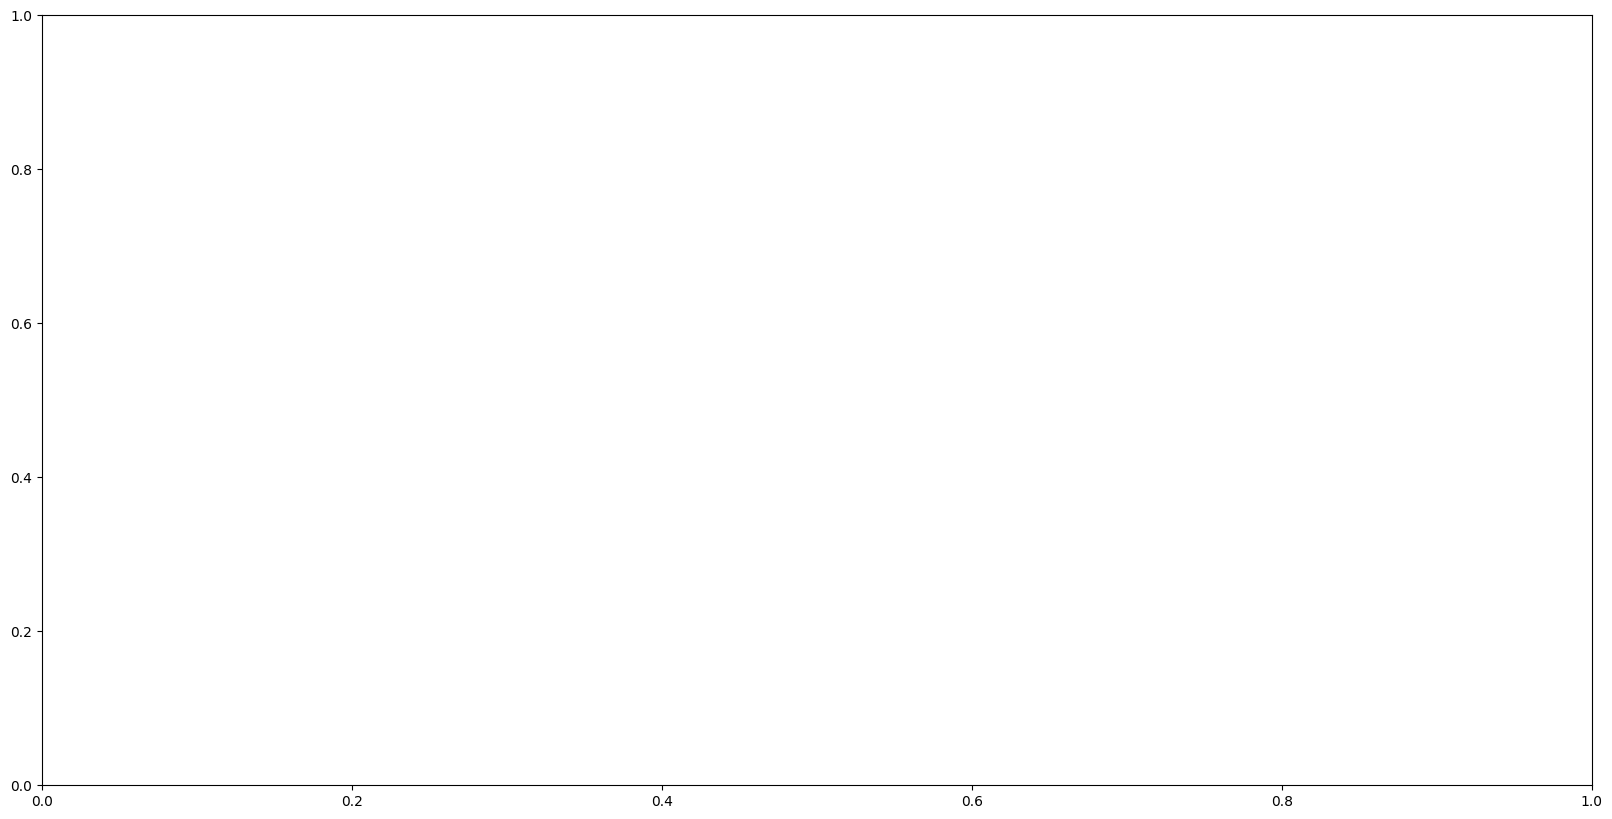

In [21]:
# for each movie make a plot of its multipliers vs the knn multipliers
def plot_multipliers(movie_id: str, multipliers: list[float], knn_multipliers: list[list[float]]):
    plt.figure(figsize=(20, 10))
    plt.plot(multipliers, label="Original Movie")
    for i, knn_multiplier in enumerate(knn_multipliers):
        plt.plot(knn_multiplier, label=f"KNN Movie {i+1}")
    plt.title(f"Multipliers for Movie {movie_id}")
    plt.xlabel("Day")
    plt.ylabel("Multiplier")
    plt.legend()
    plt.show()

for movie_id, mape_list in mape_by_movie.items():
    multipliers = multipliers_by_movie[movie_id]
    knn_multipliers = []
    for mape in mape_list:
        knn_multipliers.append(multipliers_by_movie[mape["movie_id"]])
    plot_multipliers(movie_id, multipliers, knn_multipliers)

average mape 1.4361239080799877


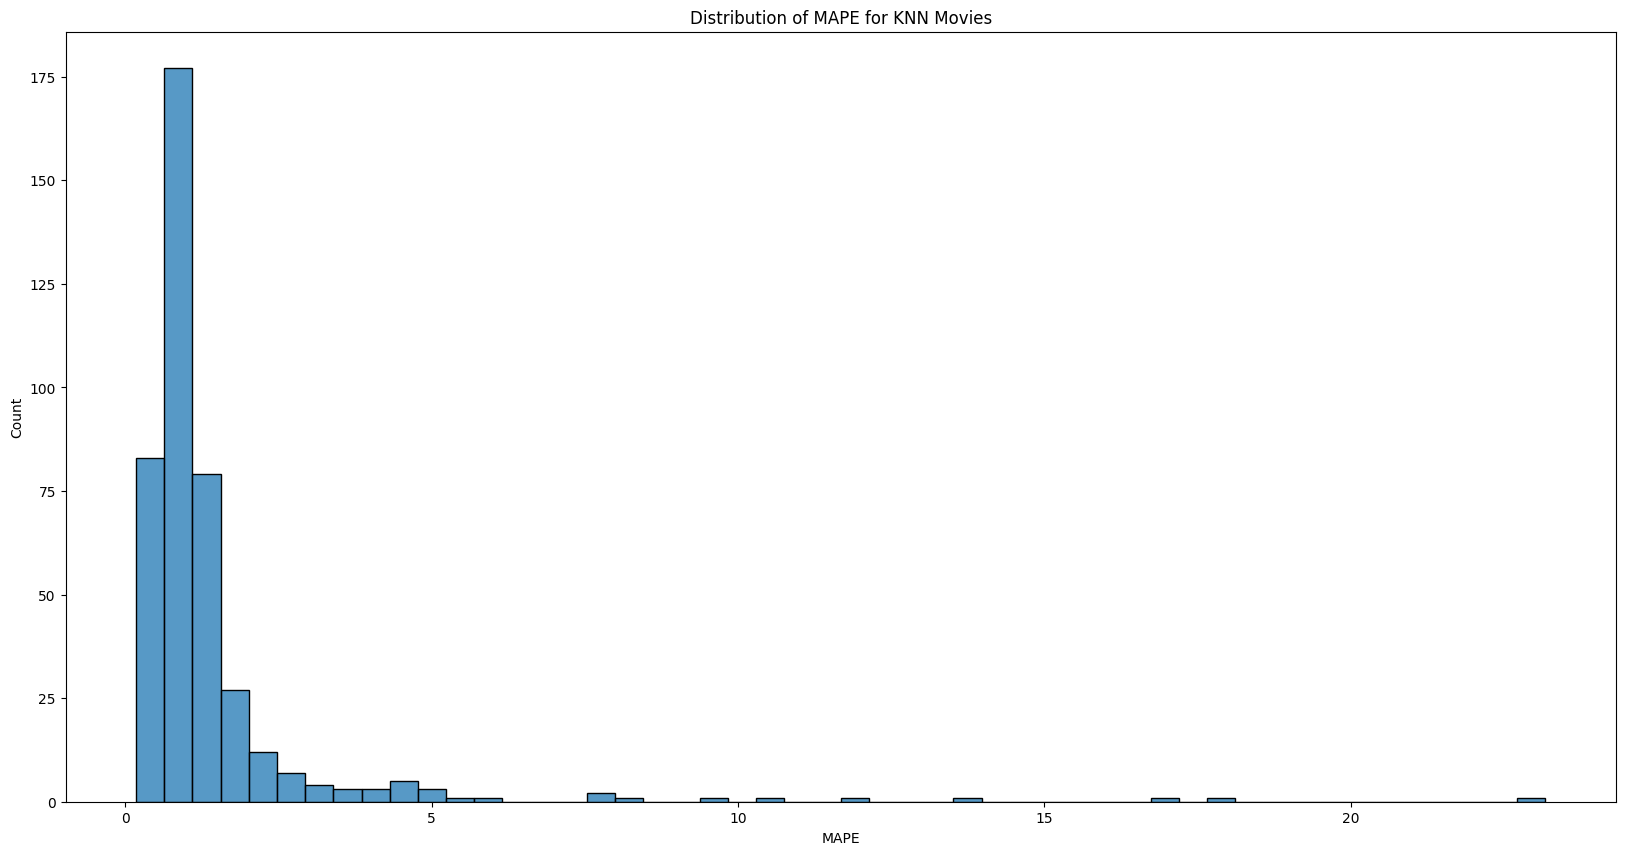

In [20]:
# plot the mape for each movie

def plot_mape(mape_by_movie: dict[str, list[MovieMape]]):
    mape_list = []
    for movie_id, mape_list_for_movie in mape_by_movie.items():
        for mape in mape_list_for_movie:
            mape_list.append(mape["mape"])

    print("average mape", statistics.mean(mape_list))

    plt.figure(figsize=(20, 10))
    sns.histplot(mape_list, bins=50)
    plt.xlabel("MAPE")
    plt.ylabel("Count")
    plt.title("Distribution of MAPE for KNN Movies")
    plt.show()
plot_mape(mape_by_movie)